This notebook creates a `Dataset` object to store data from a folder of FITS files and visualizes a sample spectrogram.

Burst detected (0=no, 1=yes): 1


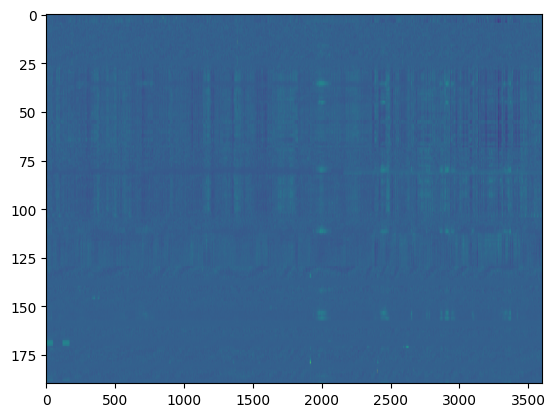

In [2]:
# Import necessary modules
import sys
import os
sys.path.append(os.path.abspath("../.."))
import utils.utils as utils
import utils.preprocessing as prep
from utils.dataset import Dataset

# Define the path to the data folder
data_path = ['C:\\Users\\15862\\OneDrive\\Documents\\Senior year assignments\\helio\\data\\FITfiles-20250205T173408Z-001.zip', 'C:\\Users\\15862\\OneDrive\\Documents\\Senior year assignments\\helio\\data\\FITfiles-20250205T173408Z-002.zip', 'C:\\Users\\15862\\OneDrive\\Documents\\Senior year assignments\\helio\\data\\FITfiles-20250205T173408Z-003.zip']
labels_path = 'C:\\Users\\15862\\OneDrive\\Documents\\Senior year assignments\\helio\\data\\metadata\\filtered-labels-20240309-20240701.csv'


# Create a Dataset object which loads all data from the given path (defined in dataset.py)
data = Dataset(data_dir= data_path,
              labels= labels_path,
              preprocess=prep.stan_rows_remove_verts,
              zip=True)

# Get the first spectrogram in the dataset
batch = data[0]
label = batch['label']
spec_data = batch['spectrogram']
# Plot first spectrogram
print(f'Burst detected (0=no, 1=yes): {label}')
utils.plot_spectrogram(spec_data)

In [5]:
# New datasets can be created by keeping only bursts or only nonbursts

dataset_only_bursts = data.only_bursts()
dataset_only_nonbursts = data.only_nonbursts()

print(f'Length of full dataset = {len(data)}')
print(f'Length of only nonbursts dataset = {len(dataset_only_nonbursts)}')
print(f'Length of only bursts dataset = {len(dataset_only_bursts)}')

Length of full dataset = 1048
Length of only nonbursts dataset = 965
Length of only bursts dataset = 83
